In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os, gc, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

base = '/content/drive/MyDrive/IDS_Africa_ML/'

import psutil
ram = psutil.virtual_memory()
print(f"Total RAM     : {ram.total    / 1024**3:.1f} GB")
print(f"Available RAM : {ram.available / 1024**3:.1f} GB")
print(f"Used RAM      : {ram.used     / 1024**3:.1f} GB")
print("\nAll libraries loaded and Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total RAM     : 12.7 GB
Available RAM : 5.6 GB
Used RAM      : 6.8 GB

All libraries loaded and Drive mounted


In [20]:
data_path = base + 'data/'

files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Found {len(files)} CSV files:\n")

dfs = []
for f in sorted(files):
    temp = pd.read_csv(data_path + f, encoding='latin-1', low_memory=False)
    print(f"  Loaded: {f:55s} -> {temp.shape[0]:>9,} rows")
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df.columns = df.columns.str.strip()

print(f"\nCombined dataset : {df.shape[0]:,} rows x {df.shape[1]} columns")

Found 8 CSV files:

  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        ->   225,745 rows
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    ->   286,467 rows
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv               ->   191,033 rows
  Loaded: Monday-WorkingHours.pcap_ISCX.csv                       ->   529,918 rows
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ->   288,602 rows
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  ->   170,366 rows
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv                      ->   445,909 rows
  Loaded: Wednesday-workingHours.pcap_ISCX.csv                    ->   692,703 rows

Combined dataset : 2,830,743 rows x 79 columns


In [21]:
before = len(df)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

after = len(df)

print("DATA CLEANING REPORT")
print("=" * 40)
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Rows removed         : {before - after:,}")
print(f"\nNull check  (should be 0): {df.isnull().sum().sum()}")
print(f"Inf check   (should be 0): {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print("\nDataset is clean")

DATA CLEANING REPORT
Rows before cleaning : 2,830,743
Rows after cleaning  : 2,827,876
Rows removed         : 2,867

Null check  (should be 0): 0
Inf check   (should be 0): 0

Dataset is clean


In [22]:
df['Label'] = df['Label'].str.strip()

label_map = {
    'Web Attack \x96 Brute Force'   : 'Web Attack',
    'Web Attack \x96 XSS'           : 'Web Attack',
    'Web Attack \x96 Sql Injection'  : 'Web Attack',
}
df['Label'] = df['Label'].replace(label_map)

print("LABEL DISTRIBUTION AFTER CLEANING")
print("=" * 40)
print(df['Label'].value_counts().to_string())
print(f"\nTotal unique classes : {df['Label'].nunique()}")
print("\nLabels standardized")

LABEL DISTRIBUTION AFTER CLEANING
Label
BENIGN                          2271320
DoS Hulk                         230124
PortScan                         158804
DDoS                             128025
DoS GoldenEye                     10293
FTP-Patator                        7935
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1956
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11

Total unique classes : 15

Labels standardized


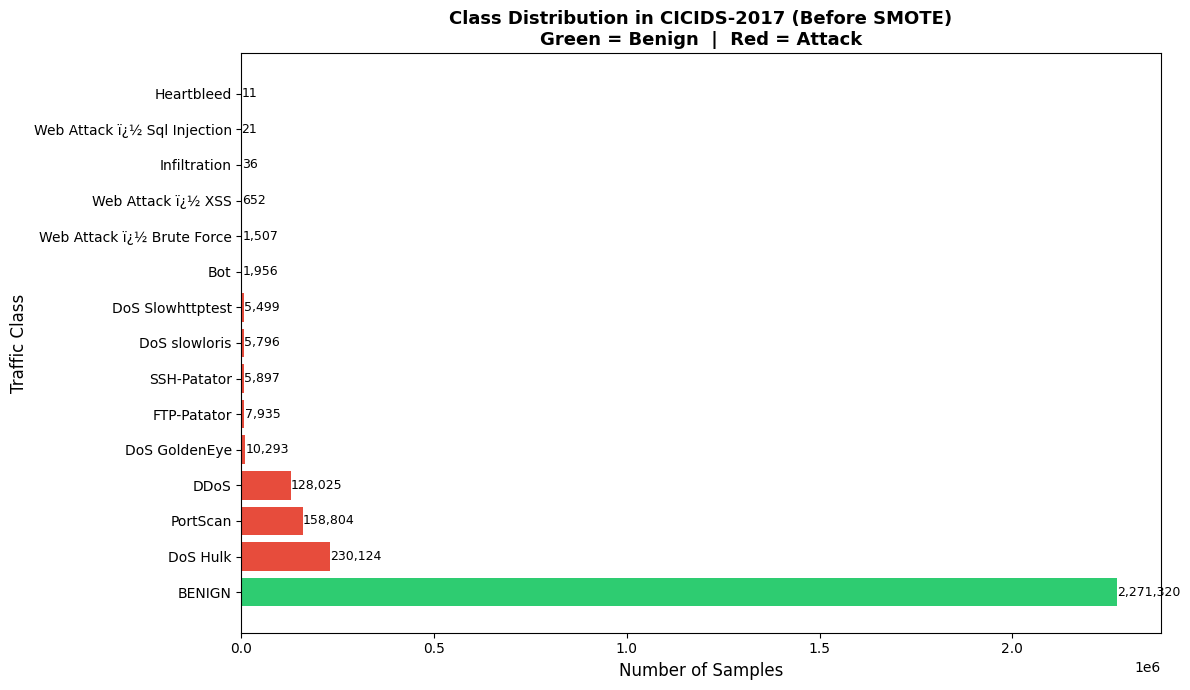

Figure saved


In [23]:
plt.figure(figsize=(12, 7))

counts_raw = df['Label'].value_counts()
colors = ['#2ecc71' if x == 'BENIGN' else '#e74c3c' for x in counts_raw.index]

bars = plt.barh(counts_raw.index, counts_raw.values, color=colors)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Traffic Class', fontsize=12)
plt.title('Class Distribution in CICIDS-2017 (Before SMOTE)\nGreen = Benign  |  Red = Attack',
          fontsize=13, fontweight='bold')

for bar, val in zip(bars, counts_raw.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(base + 'figures/02a_class_distribution_before_smote.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved")

In [24]:
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])
joblib.dump(le, base + 'models/label_encoder.pkl')

print("LABEL ENCODING MAP")
print("=" * 40)
for i, label in enumerate(le.classes_):
    count = (df['Label_encoded'] == i).sum()
    print(f"  {i:>2} -> {label:<35} ({count:,} samples)")

X = df.drop(['Label', 'Label_encoded'], axis=1)
y = df['Label_encoded']

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")

del df
gc.collect()
print("\ndf freed from RAM")
print("Label encoder saved")

LABEL ENCODING MAP
   0 -> BENIGN                              (2,271,320 samples)
   1 -> Bot                                 (1,956 samples)
   2 -> DDoS                                (128,025 samples)
   3 -> DoS GoldenEye                       (10,293 samples)
   4 -> DoS Hulk                            (230,124 samples)
   5 -> DoS Slowhttptest                    (5,499 samples)
   6 -> DoS slowloris                       (5,796 samples)
   7 -> FTP-Patator                         (7,935 samples)
   8 -> Heartbleed                          (11 samples)
   9 -> Infiltration                        (36 samples)
  10 -> PortScan                            (158,804 samples)
  11 -> SSH-Patator                         (5,897 samples)
  12 -> Web Attack ï¿½ Brute Force          (1,507 samples)
  13 -> Web Attack ï¿½ Sql Injection        (21 samples)
  14 -> Web Attack ï¿½ XSS                  (652 samples)

Feature matrix shape : (2827876, 78)
Target vector shape  : (2827876,)

df freed

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, base + 'models/scaler.pkl')

del X
gc.collect()

print("FEATURE SCALING REPORT")
print("=" * 40)
print(f"Shape after scaling     : {X_scaled.shape}")
print(f"Mean  (should be ~0.00) : {X_scaled[:, 0].mean():.4f}")
print(f"Std   (should be ~1.00) : {X_scaled[:, 0].std():.4f}")
print("\nFeatures scaled with StandardScaler")
print("Scaler saved to Drive")
print("X freed from RAM")

FEATURE SCALING REPORT
Shape after scaling     : (2827876, 78)
Mean  (should be ~0.00) : -0.0000
Std   (should be ~1.00) : 1.0000

Features scaled with StandardScaler
Scaler saved to Drive
X freed from RAM


In [26]:
from sklearn.model_selection import train_test_split as tts

_, X_sample, _, y_sample = tts(
    X_scaled, y.values,
    test_size=0.02,
    random_state=42,
    stratify=y.values
)

del X_scaled
gc.collect()

print("STRATIFIED SAMPLE REPORT")
print("=" * 40)
print(f"Sample size : {len(X_sample):,} rows (2% of full dataset)")
print(f"\nClass counts in sample:")
sample_counts = pd.Series(y_sample).value_counts()
for cls, cnt in sample_counts.items():
    print(f"  {cls:>2} -> {le.classes_[cls]:<35} ({cnt:,} samples)")

print("\nX_scaled freed from RAM")
print("Stratified sample ready")

STRATIFIED SAMPLE REPORT
Sample size : 56,558 rows (2% of full dataset)

Class counts in sample:
   0 -> BENIGN                              (45,427 samples)
   4 -> DoS Hulk                            (4,602 samples)
  10 -> PortScan                            (3,176 samples)
   2 -> DDoS                                (2,561 samples)
   3 -> DoS GoldenEye                       (206 samples)
   7 -> FTP-Patator                         (159 samples)
  11 -> SSH-Patator                         (118 samples)
   6 -> DoS slowloris                       (116 samples)
   5 -> DoS Slowhttptest                    (110 samples)
   1 -> Bot                                 (39 samples)
  12 -> Web Attack ï¿½ Brute Force          (30 samples)
  14 -> Web Attack ï¿½ XSS                  (13 samples)
   9 -> Infiltration                        (1 samples)

X_scaled freed from RAM
Stratified sample ready


In [27]:
counts = pd.Series(y_sample).value_counts()
valid_classes = counts[counts >= 5].index.tolist()
rare_classes  = counts[counts <  5].index.tolist()

print("CLASS FILTERING REPORT")
print("=" * 40)
print(f"Classes kept    : {len(valid_classes)}")
print(f"Classes dropped : {len(rare_classes)}")

if rare_classes:
    print("\nDropped (too few samples for SMOTE):")
    for c in rare_classes:
        print(f"  ID {c:>2} -> {le.classes_[c]:<35} ({counts[c]} samples)")

mask = pd.Series(y_sample).isin(valid_classes).values
X_filtered = X_sample[mask]
y_filtered = y_sample[mask]

del X_sample
gc.collect()

print(f"\nFiltered sample size : {len(X_filtered):,}")

min_samples = pd.Series(y_filtered).value_counts().min()
k = min(5, min_samples - 1)
print(f"Using k_neighbors    : {k}")

print("\nApplying SMOTE... (this may take 2-3 minutes)")
smote = SMOTE(random_state=42, k_neighbors=k)
X_balanced, y_balanced = smote.fit_resample(X_filtered, y_filtered)

del X_filtered
gc.collect()

print(f"\nSMOTE COMPLETE")
print("=" * 40)
print(f"Dataset size after SMOTE : {X_balanced.shape[0]:,} rows")
print(f"\nClass distribution after SMOTE:")
after_counts = pd.Series(y_balanced).value_counts()
for cls, cnt in after_counts.items():
    print(f"  {cls:>2} -> {le.classes_[cls]:<35} ({cnt:,} samples)")
print("\nSMOTE applied successfully")

CLASS FILTERING REPORT
Classes kept    : 12
Classes dropped : 1

Dropped (too few samples for SMOTE):
  ID  9 -> Infiltration                        (1 samples)

Filtered sample size : 56,557
Using k_neighbors    : 5

Applying SMOTE... (this may take 2-3 minutes)

SMOTE COMPLETE
Dataset size after SMOTE : 545,124 rows

Class distribution after SMOTE:
   0 -> BENIGN                              (45,427 samples)
   2 -> DDoS                                (45,427 samples)
   4 -> DoS Hulk                            (45,427 samples)
  10 -> PortScan                            (45,427 samples)
  11 -> SSH-Patator                         (45,427 samples)
   1 -> Bot                                 (45,427 samples)
   5 -> DoS Slowhttptest                    (45,427 samples)
   7 -> FTP-Patator                         (45,427 samples)
   3 -> DoS GoldenEye                       (45,427 samples)
   6 -> DoS slowloris                       (45,427 samples)
  12 -> Web Attack ï¿½ Brute Force   

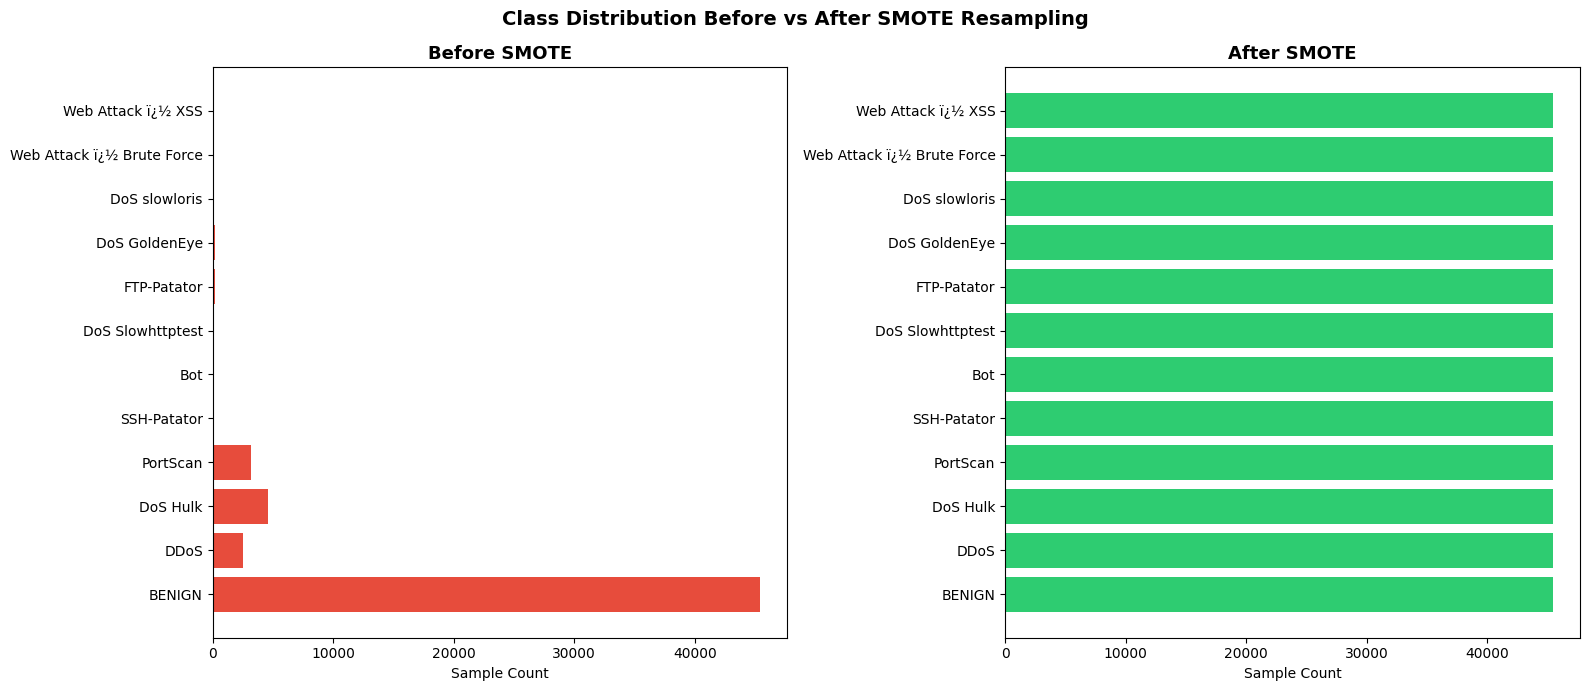

Figure saved


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

kept_classes = [le.classes_[i] for i in after_counts.index]
before_vals  = [counts.get(i, 0) for i in after_counts.index]

axes[0].barh(kept_classes, before_vals, color='#e74c3c')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Count')

axes[1].barh(kept_classes, after_counts.values, color='#2ecc71')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample Count')

plt.suptitle('Class Distribution Before vs After SMOTE Resampling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(base + 'figures/02b_smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved")

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("TRAIN / TEST SPLIT REPORT")
print("=" * 40)
print(f"Training set : {X_train.shape[0]:,} samples  |  {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} samples  |  {X_test.shape[1]} features")
print(f"\nClass balance in training set:")
for cls, cnt in pd.Series(y_train).value_counts().items():
    print(f"  {cls:>2} -> {le.classes_[cls]:<35} ({cnt:,})")
print("\nSplit complete (80% train / 20% test, stratified)")

TRAIN / TEST SPLIT REPORT
Training set : 436,099 samples  |  78 features
Test set     : 109,025 samples  |  78 features

Class balance in training set:
  10 -> PortScan                            (36,342)
  11 -> SSH-Patator                         (36,342)
   5 -> DoS Slowhttptest                    (36,342)
   2 -> DDoS                                (36,342)
  12 -> Web Attack ï¿½ Brute Force          (36,342)
   1 -> Bot                                 (36,342)
   0 -> BENIGN                              (36,342)
  14 -> Web Attack ï¿½ XSS                  (36,341)
   3 -> DoS GoldenEye                       (36,341)
   7 -> FTP-Patator                         (36,341)
   6 -> DoS slowloris                       (36,341)
   4 -> DoS Hulk                            (36,341)

Split complete (80% train / 20% test, stratified)


In [30]:
np.save(base + 'outputs/X_train.npy', X_train)
np.save(base + 'outputs/X_test.npy',  X_test)
np.save(base + 'outputs/y_train.npy', y_train)
np.save(base + 'outputs/y_test.npy',  y_test)

print("ALL OUTPUTS SAVED TO DRIVE")
print("=" * 40)
print(f"  X_train.npy        -> {X_train.shape}")
print(f"  X_test.npy         -> {X_test.shape}")
print(f"  y_train.npy        -> {y_train.shape}")
print(f"  y_test.npy         -> {y_test.shape}")
print(f"  label_encoder.pkl  OK")
print(f"  scaler.pkl         OK")
print(f"\n  figures/02a_class_distribution_before_smote.png  OK")
print(f"  figures/02b_smote_comparison.png                  OK")
print("\n" + "=" * 40)
print("PREPROCESSING COMPLETE")
print("Next step: Notebook 03 — Model Training")
print("=" * 40)

ALL OUTPUTS SAVED TO DRIVE
  X_train.npy        -> (436099, 78)
  X_test.npy         -> (109025, 78)
  y_train.npy        -> (436099,)
  y_test.npy         -> (109025,)
  label_encoder.pkl  OK
  scaler.pkl         OK

  figures/02a_class_distribution_before_smote.png  OK
  figures/02b_smote_comparison.png                  OK

PREPROCESSING COMPLETE
Next step: Notebook 03 — Model Training
